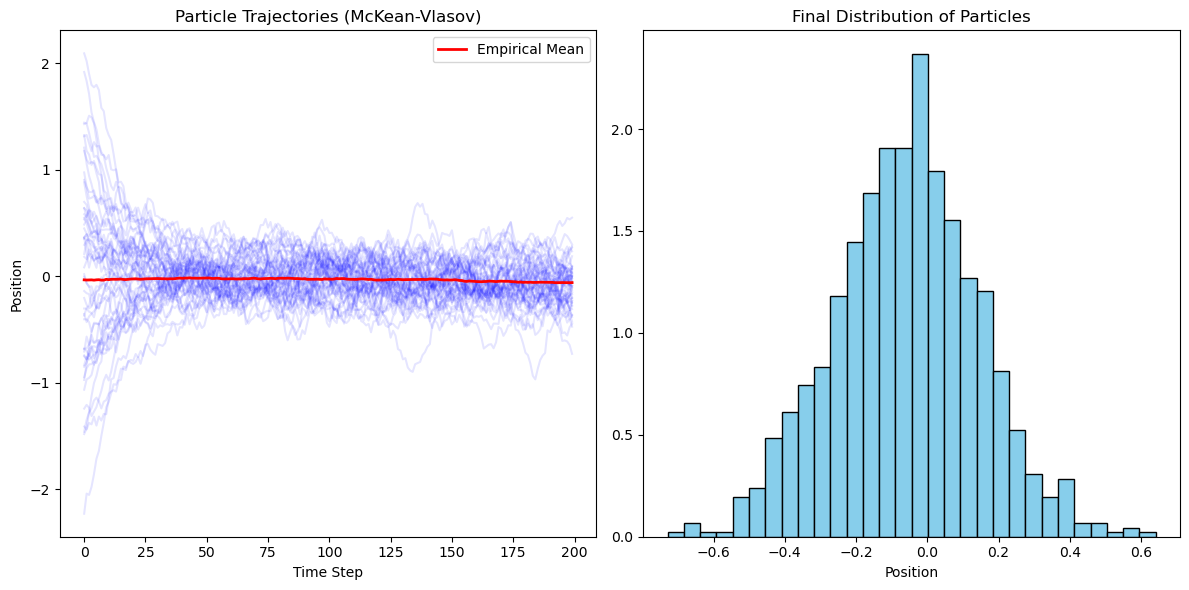

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters
n_particles = 1000    # Size of the "crowd"
n_steps = 200         # Time steps
dt = 0.1              # Time increment
alpha = 0.5           # Strength of mean-field interaction
sigma = 0.2           # Diffusion (randomness) strength

# 2. Initialization
# Particles start scattered in a normal distribution
X = np.random.randn(n_particles)
history = np.zeros((n_steps, n_particles))

# 3. Simulation (Euler-Maruyama Method)
for t in range(n_steps):
    # Calculate the mean of the entire population at this instant
    # This is the "Vlasov" part: the distribution affects the drift
    mu_t = np.mean(X)
    
    # Standard Brownian Motion increment
    dW = np.random.normal(0, np.sqrt(dt), n_particles)
    
    # McKean-Vlasov update:
    # dX = alpha * (Mean - X) * dt + sigma * dW
    X += alpha * (mu_t - X) * dt + sigma * dW
    
    history[t, :] = X

# 4. Visualization
plt.figure(figsize=(12, 6))

# Plot the trajectories of the first 50 particles
plt.subplot(1, 2, 1)
plt.plot(history[:, :50], color='blue', alpha=0.1)
plt.plot(np.mean(history, axis=1), color='red', linewidth=2, label='Empirical Mean')
plt.title("Particle Trajectories (McKean-Vlasov)")
plt.xlabel("Time Step")
plt.ylabel("Position")
plt.legend()

# Plot the final distribution
plt.subplot(1, 2, 2)
plt.hist(history[-1, :], bins=30, color='skyblue', edgecolor='black', density=True)
plt.title("Final Distribution of Particles")
plt.xlabel("Position")

plt.tight_layout()
plt.show()